#  Data Cleanning

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings("ignore")


In [6]:
import pandas as pd

df=pd.read_csv("retail_sales_dataset.csv")  # Load the dataset
print(df.head())   # print 1st 5 five 
print("\nColumns:",df.columns)   # print columns
print("\nData Info:")
print(df.info()) # print the information about the data


   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  

Columns: Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns

In [7]:
# To fix Capital Letters ,Spaces, Inconsistent naming
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print(df.columns)

Index(['transaction_id', 'date', 'customer_id', 'gender', 'age',
       'product_category', 'quantity', 'price_per_unit', 'total_amount'],
      dtype='object')


In [8]:
df['date']=pd.to_datetime(df['date'],errors='coerce')
df=df.dropna(subset=['date'])

In [9]:
# Sorting the time series
df=df.sort_values('date')
    

In [10]:
#Check missing values
df.isnull().sum()

transaction_id      0
date                0
customer_id         0
gender              0
age                 0
product_category    0
quantity            0
price_per_unit      0
total_amount        0
dtype: int64

In [17]:
# rename
df=df.rename(columns={'quantity':'sales'})
print(df.columns)

Index(['transaction_id', 'date', 'customer_id', 'gender', 'age',
       'product_category', 'sales', 'price_per_unit', 'total_amount'],
      dtype='object')


In [19]:
# handle missing values

df['calculated_amount']=df['sales']*df['price_per_unit']
df[['sales','price_per_unit','total_amount','calculated_amount']].head()

,sales,price_per_unit,total_amount,calculated_amount
521,3,500,1500,1500
179,3,300,900,900
558,4,300,1200,1200
302,3,30,90,90
978,1,25,25,25


# EDA
## sales Trend

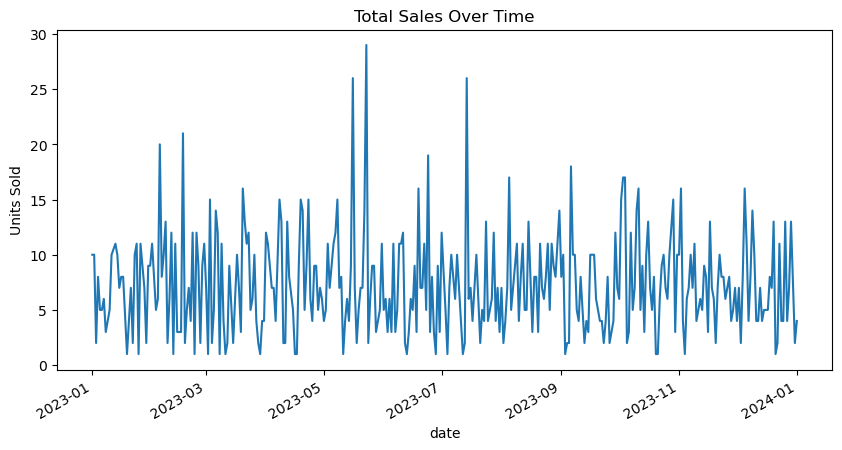

In [22]:
plt.figure(figsize=(10,5))
df.groupby('date')['sales'].sum().plot()
plt.title("Total Sales Over Time")
plt.ylabel("Units Sold")
plt.show()

## Sales Distribution

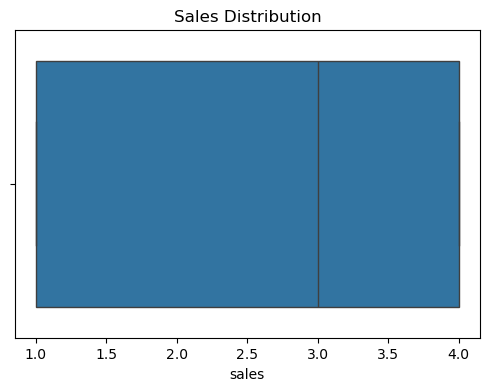

In [25]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['sales'])
plt.title("Sales Distribution")
plt.show()

# Feature Engineering

## Time Feature

In [29]:
df['day_of_week']=df['date'].dt.dayofweek
df['month']=df['date'].dt.month
df['week_of_year']=df['date'].dt.isocalendar().week.astype(int)
df['is_weekend']=df['day_of_week'].isin([5,6]).astype(int)
df[['date','day_of_week','month','week_of_year','is_weekend']].head() # to see the columns added

,date,day_of_week,month,week_of_year,is_weekend
521,2023-01-01,6,1,52,1
179,2023-01-01,6,1,52,1
558,2023-01-01,6,1,52,1
302,2023-01-02,0,1,1,0
978,2023-01-02,0,1,1,0


In [31]:
## Log Features
df['sales_lag_1']=df.groupby('product_category')['sales'].shift(1)
df['sales_lag_7'] = df.groupby('product_category')['sales'].shift(7)
df['sales_lag_14'] = df.groupby('product_category')['sales'].shift(14)
df[['product_category', 'date', 'sales', 'sales_lag_1', 'sales_lag_7']].head() # to chcek

,product_category,date,sales,sales_lag_1,sales_lag_7
521,Beauty,2023-01-01,3,NaN,NaN
179,Clothing,2023-01-01,3,NaN,NaN
558,Clothing,2023-01-01,4,3.0,NaN
302,Electronics,2023-01-02,3,NaN,NaN
978,Beauty,2023-01-02,1,3.0,NaN


## Rolling Feature

In [34]:
df['rolling_mean_7']=df.groupby('product_category')['sales'].shift(1).rolling(7).mean()
df['rolling_mean_14']=df.groupby('product_category')['sales'].shift(1).rolling(14).mean()
df[['product_category', 'sales', 'rolling_mean_7', 'rolling_mean_14']].head(20) # to check

,product_category,sales,rolling_mean_7,rolling_mean_14
521,Beauty,3,NaN,NaN
179,Clothing,3,NaN,NaN
558,Clothing,4,NaN,NaN
302,Electronics,3,NaN,NaN
978,Beauty,1,NaN,NaN
162,Clothing,3,NaN,NaN
420,Clothing,3,NaN,NaN
609,Beauty,2,NaN,NaN
682,Beauty,2,NaN,NaN
230,Clothing,3,NaN,NaN


In [36]:
df=df.dropna()

# Train-Test Split

In [43]:
features=[
    'day_of_week','month','week_of_year','is_weekend',
    'sales_lag_1','sales_lag_7','sales_lag_14','rolling_mean_7','rolling_mean_14'
]
X=df[features]
y=df['sales']

X_train,X_test,y_train,y_test=train_test_split(
         X,y,test_size=0.2,shuffle=False
)

## Train Demand Forecasting Model

In [54]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
model.fit(X_train,y_train)

RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

## Model Evaluation

In [59]:
y_pred=model.predict(X_test)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mean_squared_error(y_test,y_pred))

print("MAE:",mae)
print("RMSE:",rmse)

MAE: 1.0056336947363664
RMSE: 1.1784485881778723


## Demand Forecast For Next 7 days

In [64]:
latest_data=df.groupby('product_category').tail(1)
future_predictions=model.predict(latest_data[features])
latest_data['predicted_daily_demand']=future_predictions
latest_data[['product_category','predicted_daily_demand']].head()

,product_category,predicted_daily_demand
663,Clothing,2.973065
210,Beauty,2.188268
649,Electronics,2.181243


## Stockout Prediction Logic (CORE BUSINESS PART)

In [67]:
if 'inventory' in latest_data.columns:
    latets_data['days_to_stockout']=(
        latest_data['inventory']/latest_data['predicted_daily_demand']
    )

## Stockout Alerts

In [74]:
print(latest_data.columns)

Index(['transaction_id', 'date', 'customer_id', 'gender', 'age',
       'product_category', 'sales', 'price_per_unit', 'total_amount',
       'calculated_amount', 'day_of_week', 'month', 'week_of_year',
       'is_weekend', 'sales_lag_1', 'sales_lag_7', 'sales_lag_14',
       'rolling_mean_7', 'rolling_mean_14', 'predicted_daily_demand'],
      dtype='object')


In [78]:
latest_data['inventory'] = (
    latest_data['predicted_daily_demand'] * 14
)

In [82]:

latest_data['days_to_stockout'] = (
    latest_data['inventory'] /
    latest_data['predicted_daily_demand'].replace(0, np.nan)
)

In [84]:
LEAD_TIME=7
latest_data['stockout_risk']=np.where(
    latest_data['days_to_stockout']<=LEAD_TIME,
    "HIGH RISK",
    "SAFE"
)
latest_data[['product_category','inventory','predicted_daily_demand','days_to_stockout','stockout_risk']].head()

,product_category,inventory,predicted_daily_demand,days_to_stockout,stockout_risk
663,Clothing,41.622905,2.973065,14.0,SAFE
210,Beauty,30.635749,2.188268,14.0,SAFE
649,Electronics,30.537398,2.181243,14.0,SAFE


# Final Business Output

In [87]:
stockout_alerts = latest_data[
    latest_data['stockout_risk'] == "HIGH RISK"
]

stockout_alerts.sort_values('days_to_stockout').head(10)

,transaction_id,date,customer_id,gender,age,product_category,sales,price_per_unit,total_amount,calculated_amount,...,is_weekend,sales_lag_1,sales_lag_7,sales_lag_14,rolling_mean_7,rolling_mean_14,predicted_daily_demand,inventory,days_to_stockout,stockout_risk


In [89]:
latest_data.to_csv("inventory_forecast_results.csv", index=False)